---
title: Joint probability inference
---

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
)
set_log_level('WARNING')
import sys
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
from vscodenb import set_vscode_theme
sns.set_palette('tab10')
set_vscode_theme()
all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
_pytest = "pytest" in sys.modules

# set_log_level('DEBUG')

## Discrete feature joint probability

If you have access to marginal features like counts of mutations shared by your samples (singletons, doubletons etc.), You can compute the joint probability of such events exactly.

## Coalescent

In [2]:
nr_samples = 4
indexer = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples),
    ]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue 
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions



Step one is to construct the model graph.

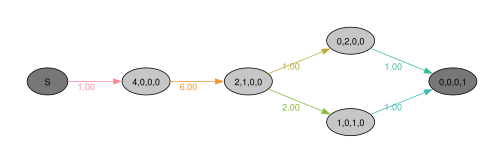

In [3]:
graph = Graph(coalescent_1param)
graph.plot()

From the model graph we can now create an augmented discrete graph that allow us to compute joint probabilities. This graph is generated for this purpose only and does not otherwise represent the original model. The trick is to track all combinations of events. Each combination is represented by a state with the absorbing one as its only child making each of them the last state in a path through the graph. The probability of passing through one such state thus represents a joint probability. Because we cannot model infinitely many combinations of discrete events, we cap the number of allowed events and route all additional events to an infinite loop not contributing to any joint probability thus defining the distributions deficit.

## Controls

In [4]:
reward_limit = 5
mutation_rate = 1e-4
pop_size = 10_000
theta = 1/pop_size

1/theta * mutation_rate

1.0

In [5]:
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_limit=reward_limit, 
                                          mutation_rate=mutation_rate)
joint_prob_graph.vertices_length()

514

Note that the edges now have, not one, but two coefficients. The extra one holds a value scaling the mutation rate.

In [6]:
joint_prob_graph.param_length()

2

Update edge weights to make the model reflect our true parameter values:

In [7]:
true_theta = [theta, mutation_rate]
joint_prob_graph.update_weights(true_theta)
joint_prob_graph.plot(nodesep=0.3)

Graph has too many nodes (514). Please set max_nodes to a higher value.


Compute the joint probabilities:

In [8]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
9,0,0,0,0,9.996334e-01
19,0,1,0,0,9.994669e-05
21,1,0,0,0,1.999023e-04
24,0,0,1,0,6.662890e-05
36,0,2,0,0,1.665434e-08
...,...,...,...,...,...
505,3,5,5,0,6.940044e-53
506,5,4,5,0,1.485583e-55
507,5,5,4,0,4.186802e-56


In [9]:
ax = plt.subplot(111)
ax.axhline(1, c='red', ls=':', lw=1)
ax.plot(joint_prob_table.prob.cumsum()) ;

Deficit:

In [10]:
(1 - joint_prob_table['prob'].sum()).item()

1.1102230246251565e-16

### Test data

For testing and demonstration purposes, we can sample observations from the model.

In [11]:
def sample_joint_observations(joint_prob_graph, theta, nr_observations):
    joint_prob_graph.update_weights(theta) 
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

In [12]:
true_theta = [theta, mutation_rate] # coalescent rate and mutation rate
observations = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=10000)
observations[:5]

[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

For real data, make sure to only to include observations that are possible under the model:

```python
modelled_obs = joint.loc[sample, joint.columns[:-1]].to_numpy().tolist()
allowed_observations = set(tuple(x) for x in modelled_obs)
observations = [o for o in observations if tuple(o) in allowed_observations]
observations = np.array(observations)
observations
```

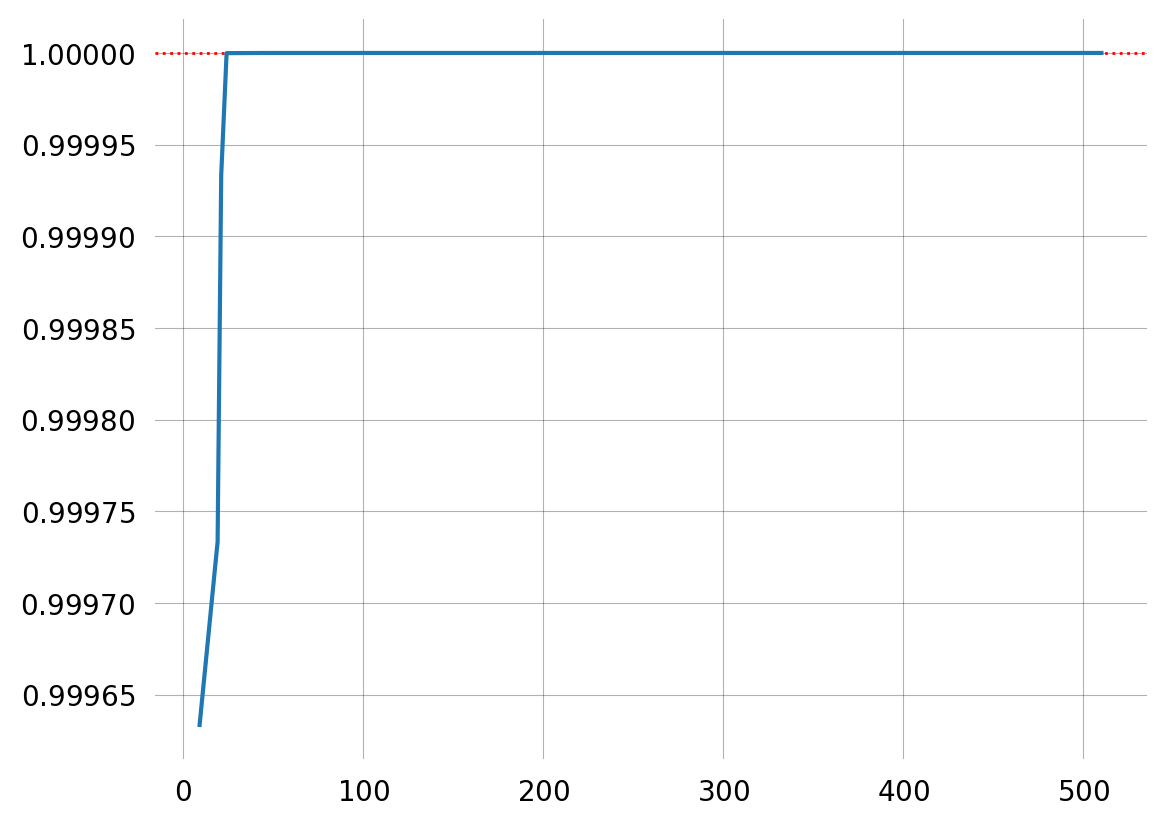

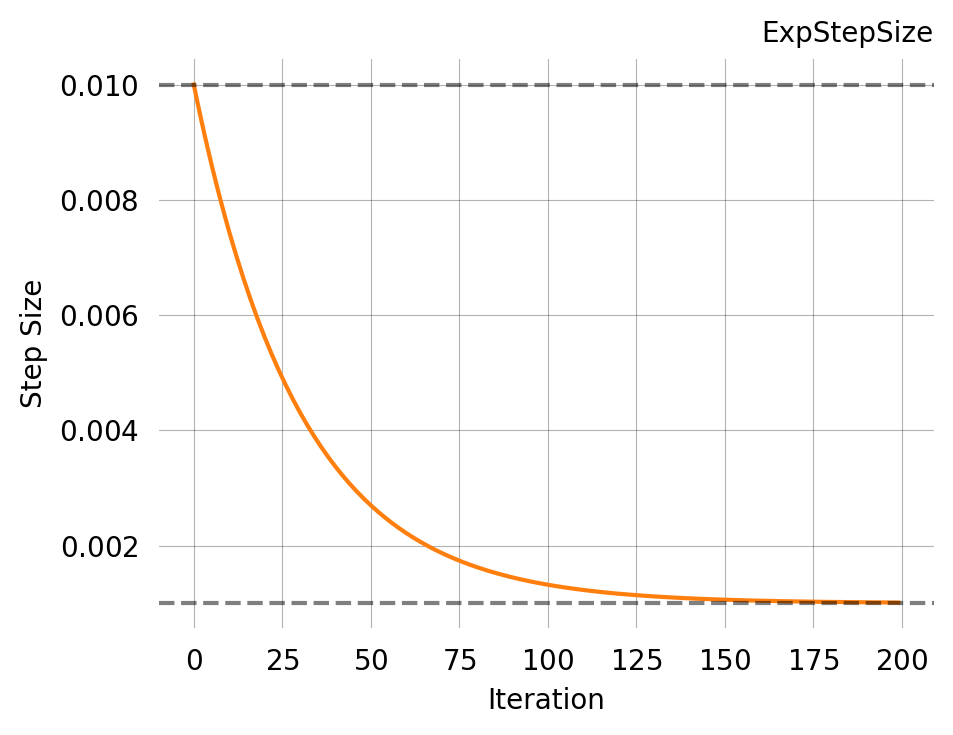

In [13]:
learning_rate = ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0)
learning_rate.plot(200) ;

<Axes: title={'right': 'LogNormal(-9.7, 0.59)'}, xlabel='Parameter value (θ)', ylabel='Density'>

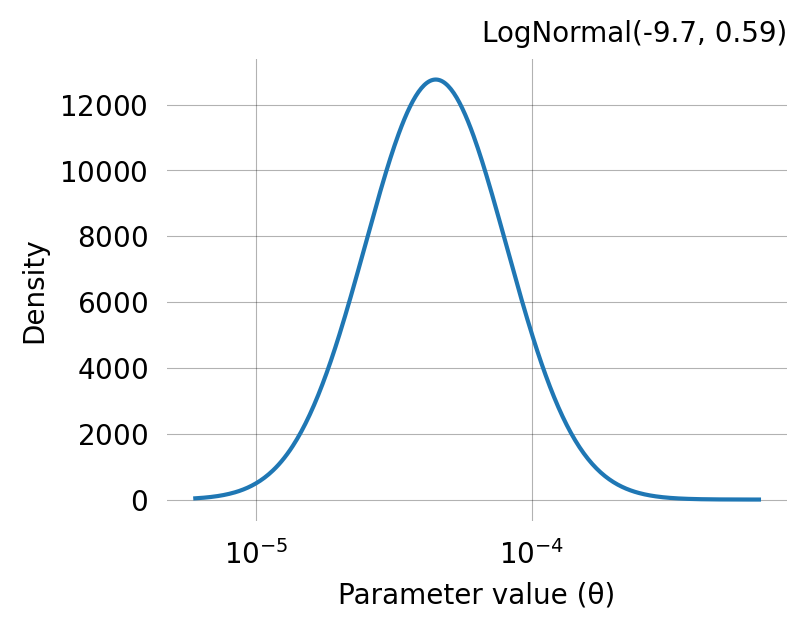

In [14]:
from phasic import LogGaussPrior
LogGaussPrior(ci=[1/50_000, 1/5000]).plot()

In [15]:
svgd = joint_prob_graph.svgd(
    observations, 
    fixed=[(1, mutation_rate)], 
    n_iterations=100,
    prior=LogGaussPrior(ci=[1/50_000, 1/5000]),
    # optimizer=Adamelia(learning_rate=0.2),
    optimizer=Adamelia(learning_rate=0.2),
    # learning_rate=learning_rate,
    # regularization=ExpRegularization(first_reg=10.0, last_reg=0.1, tau=20.0),
    )

In [16]:
svgd.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.0001     0.0001     0.0000     0.0001       0.0001      
1          Yes        0.0001     NA         NA         NA           NA          

Particles: 40, Iterations: 100


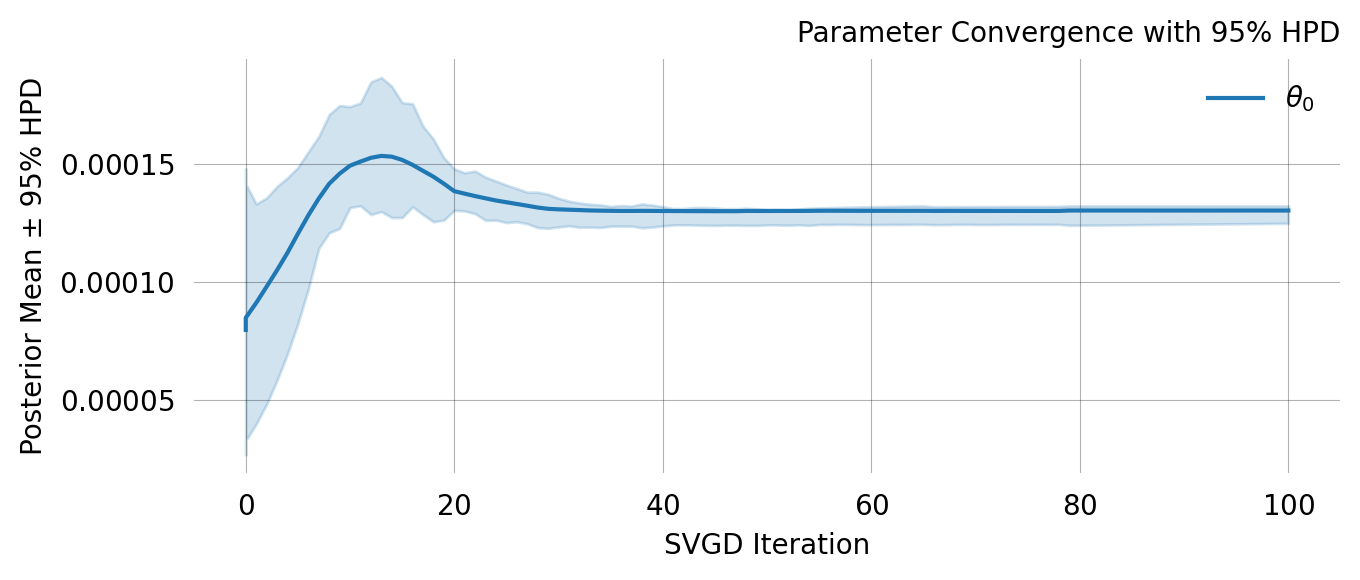

In [17]:
svgd.plot_ci(ci_method='hpd')

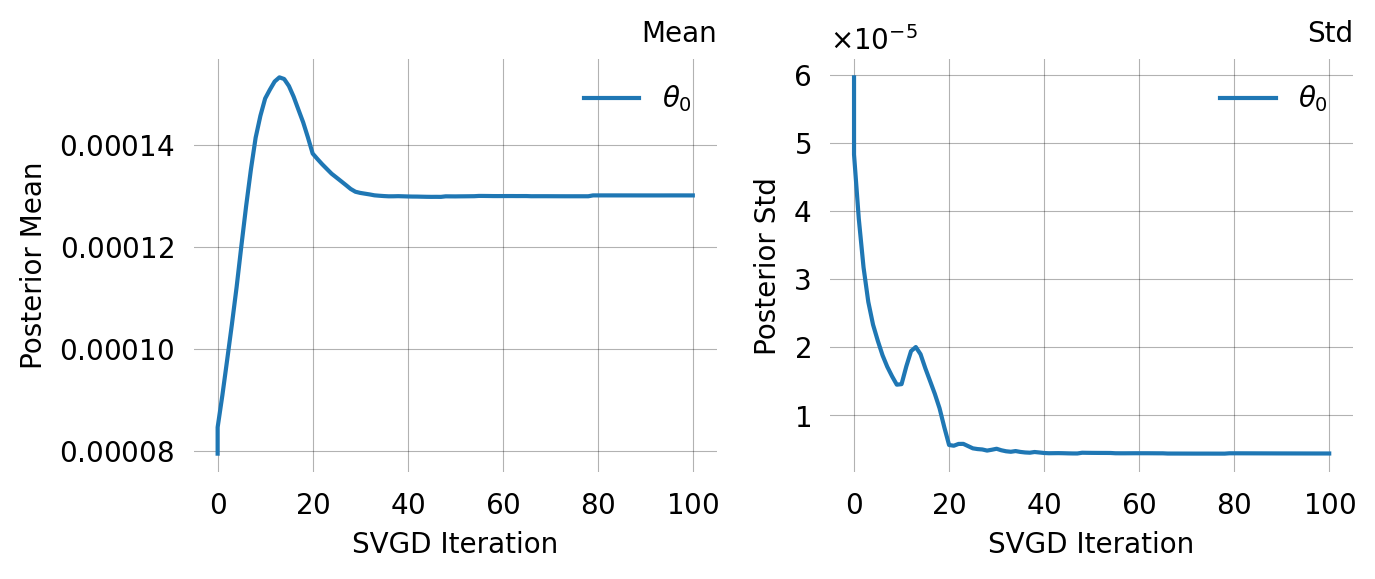

In [18]:
svgd.plot_convergence()

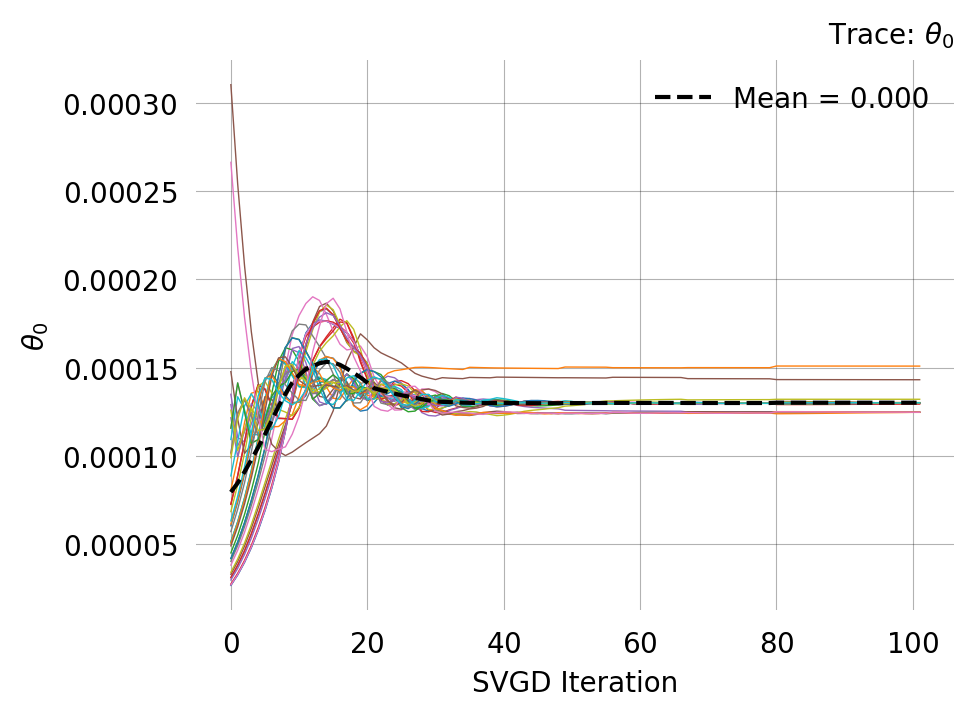

In [19]:
svgd.plot_trace()

## Epoch-wise time-inhomogeneous models

If you use the `epoch_starts` keyword argument to supply a list of epoch start times, SVGD will estimate a set of parameters for each epoch. Note that the the first epoch start must always be zero. E.g., `epoch_starts=[0, 0.5]` specifies two epochs. One starting at time zero and one starting at time 0.5.

In [21]:
joint_prob_graph_cont = graph.joint_prob_graph(indexer, reward_limit=reward_limit, mutation_rate=mutation_rate, 
                                          discrete=False)
svgd = joint_prob_graph_cont.svgd(
    observations, 
    fixed=[(1, mutation_rate)], 
    n_iterations=100,
    prior=GaussPrior(ci=[1, 5]), # WITHOUT A PRIOR IT HANGS... MAYBE BECAUSE THE NORMAL MOMENTS-BASED SCHEME IS NOT AVAILABLE FOR JOINT GRAPHS
    optimizer=Adamelia(learning_rate=0.2),
    # learning_rate=learning_rate,

    # daisy_chain_t_eval=30,
    daisy_chain_t_eval='auto',
    daisy_chain_t_eval_tol=1e-6,           # default; tighter = more conservative
    # daisy_chain_probe_theta=[5.0, 1.0],    # optional; defaults to ones

    # epoch_starts=[0, 0.02380952, 0.07142857],
    epoch_starts=[0, 0.05371094, 0.15234375]
    # epoch_starts=[0, 0.20996094, 0.4921875, 0.89648437, 1.58886719]
    # epoch_starts=[0, 0.01269531, 0.02832031, 0.046875, 0.06933594]#, 0.09472656, 0.12597656, 0.16699219, 0.22460938, 0.32421875]
#    epoch_starts=[0, 0.09667969, 0.20996094, 0.33984375, 0.4921875] #,0.67382812,  0.89648437, 1.18359375, 1.58886719, 2.28125   ]    
    # epoch_starts=[0, 0.20996094, 0.4921875]#, 0.89648437, 1.58886719]
    # epoch_starts=[0, 0.38769531]#, 1.078125]
    )

In [22]:
svgd.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.3792     7.3549     0.2660     6.7501       7.7747      
1          Yes        1.0000     NA         NA         NA           NA          
2          No         6.8114     7.0207     0.5731     6.3993       8.2920      
3          Yes        1.0000     NA         NA         NA           NA          
4          No         7.1993     6.9923     0.4397     5.9002       7.6145      
5          Yes        1.0000     NA         NA         NA           NA          

Particles: 120, Iterations: 100


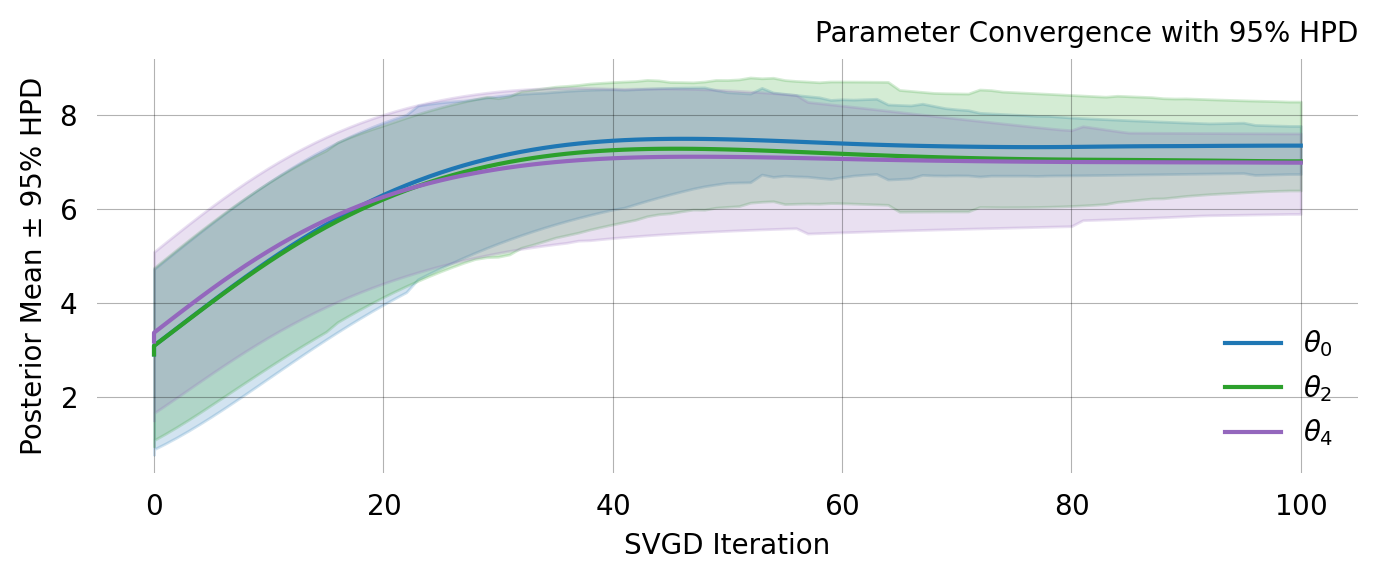

In [23]:
svgd.plot_ci(ci_method='hpd')

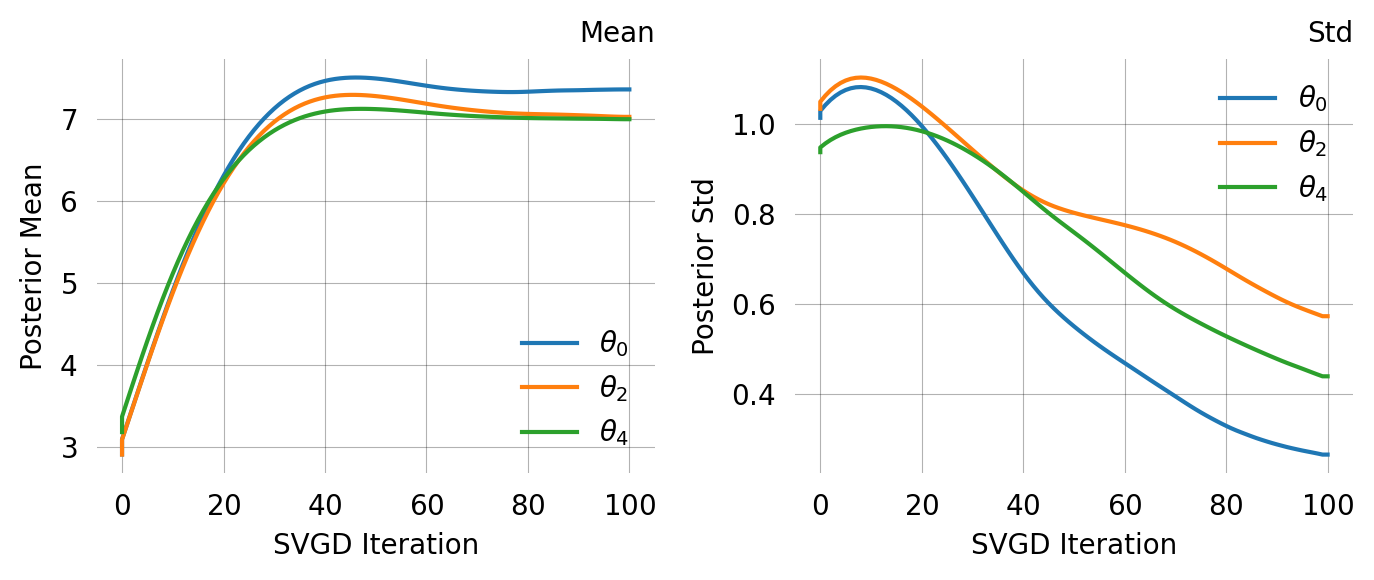

In [24]:
svgd.plot_convergence()

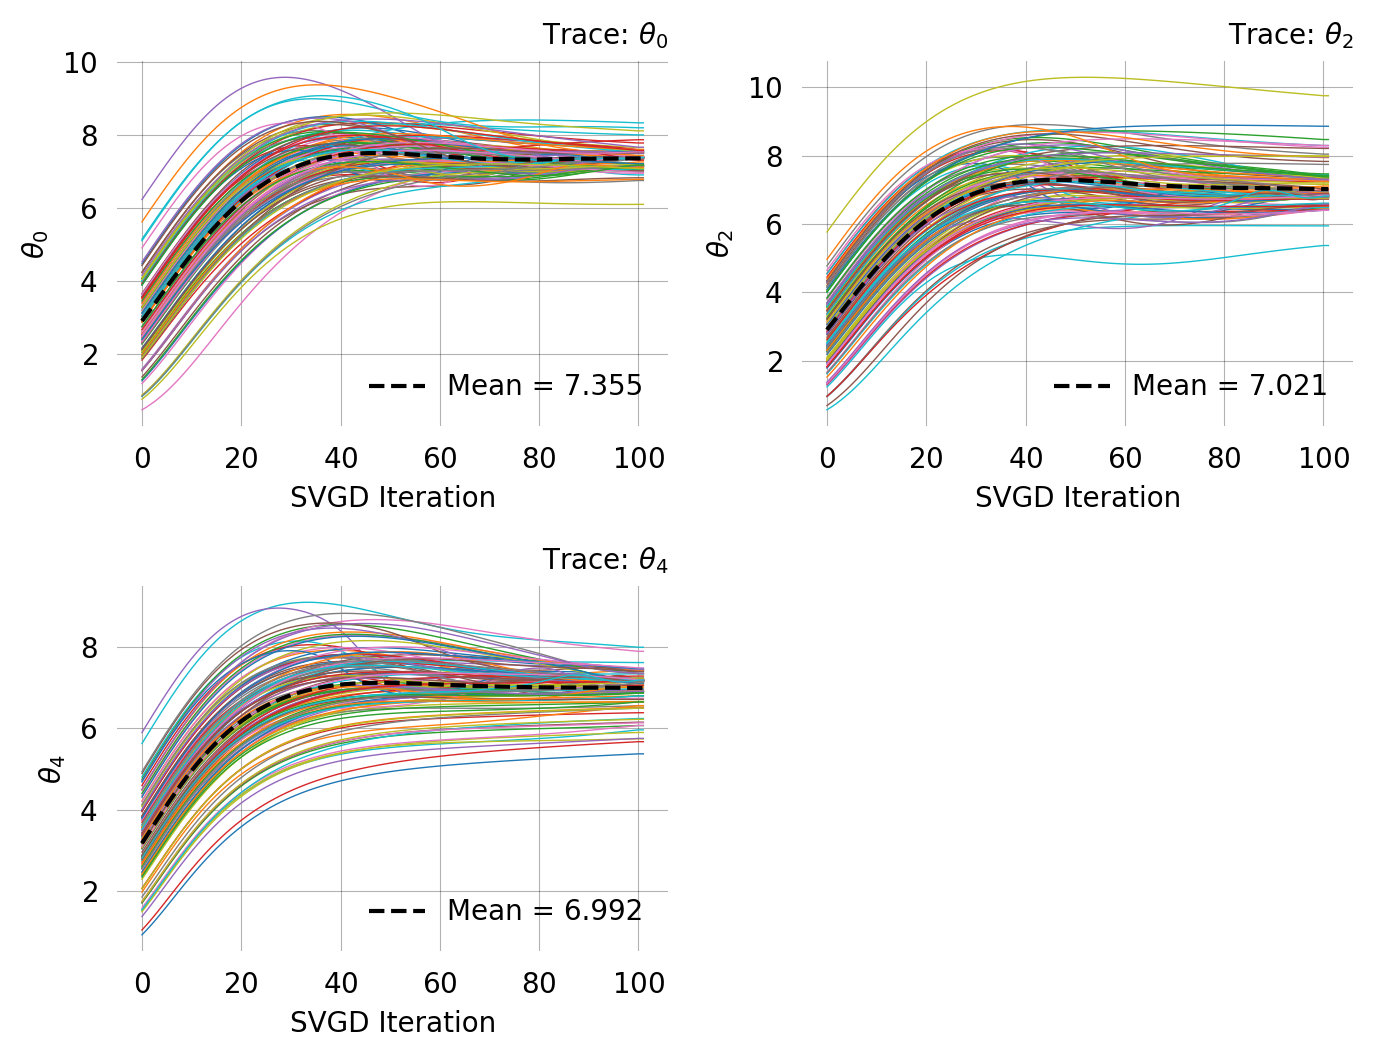

In [25]:
svgd.plot_trace()

In [ ]:
10_000 * 1e-4

1.0

: 

In [ ]:
import msprime

mut_rate = 1.0e-8
# mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
epoch_starts = [0, 0.05371094, 0.15234375]
epoch_pop_sizes = [10_000, 1_000]

demography = msprime.Demography()
demography.add_population(name="pop", initial_size=epoch_pop_sizes[0])
# for s, t in zip(epoch_starts[1:], epoch_pop_sizes[1:]):
#     demography.add_population_parameters_change(time=t, initial_size=s, population="pop")

ts = msprime.sim_ancestry(samples={"pop": nr_samples}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)

observations = []
for i, tree in enumerate(ts.trees()):
    start, end = tree.interval
    obs = np.zeros(nr_samples-1)
    for site in tree.sites():
        for mut in site.mutations:
            ton = len(list(tree.get_leaves(mut.node)))
            obs[ton-1] += 1
    observations.append(obs)

lst = []
for obs in observations:
    if max(obs) <= reward_limit:
        obs = list(map(int, obs))
        obs[-1] = 0
        lst.append(obs)
observations = lst     

# observations = np.array(observations, dtype=int)
# plt.hist(list(observations.flat), bins=100)

In [ ]:
joint_prob_graph_cont = graph.joint_prob_graph(indexer, reward_limit=reward_limit, mutation_rate=mutation_rate, 
                                          discrete=False)
svgd = joint_prob_graph_cont.svgd(
    observations, 
    fixed=[(1, mutation_rate)], 
    n_iterations=100,
    prior=GaussPrior(ci=[0.5, 5]), # WITHOUT A PRIOR IT HANGS... MAYBE BECAUSE THE NORMAL MOMENTS-BASED SCHEME IS NOT AVAILABLE FOR JOINT GRAPHS
    optimizer=Adamelia(learning_rate=0.2),
    # learning_rate=learning_rate,

    # daisy_chain_t_eval=30,
    daisy_chain_t_eval='auto',
    daisy_chain_t_eval_tol=1e-6,           # default; tighter = more conservative
    # daisy_chain_probe_theta=[5.0, 1.0],    # optional; defaults to ones

    # epoch_starts=[0, 0.02380952, 0.07142857],
    epoch_starts=[0, 0.05371094, 0.15234375]
    # epoch_starts=[0, 0.20996094, 0.4921875, 0.89648437, 1.58886719]
    # epoch_starts=[0, 0.01269531, 0.02832031, 0.046875, 0.06933594]#, 0.09472656, 0.12597656, 0.16699219, 0.22460938, 0.32421875]
#    epoch_starts=[0, 0.09667969, 0.20996094, 0.33984375, 0.4921875] #,0.67382812,  0.89648437, 1.18359375, 1.58886719, 2.28125   ]    
    # epoch_starts=[0, 0.20996094, 0.4921875]#, 0.89648437, 1.58886719]
    # epoch_starts=[0, 0.38769531]#, 1.078125]
    )

In [ ]:
svgd.summary(ci_method='hpd', ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         1.4292     1.3608     0.4907     0.6432       1.5100      
1          Yes        1.0000     NA         NA         NA           NA          
2          No         0.0539     0.3524     1.1927     0.0457       0.8616      
3          Yes        1.0000     NA         NA         NA           NA          
4          No         4.5114     4.4321     0.3761     4.2716       4.6524      
5          Yes        1.0000     NA         NA         NA           NA          

Particles: 120, Iterations: 100


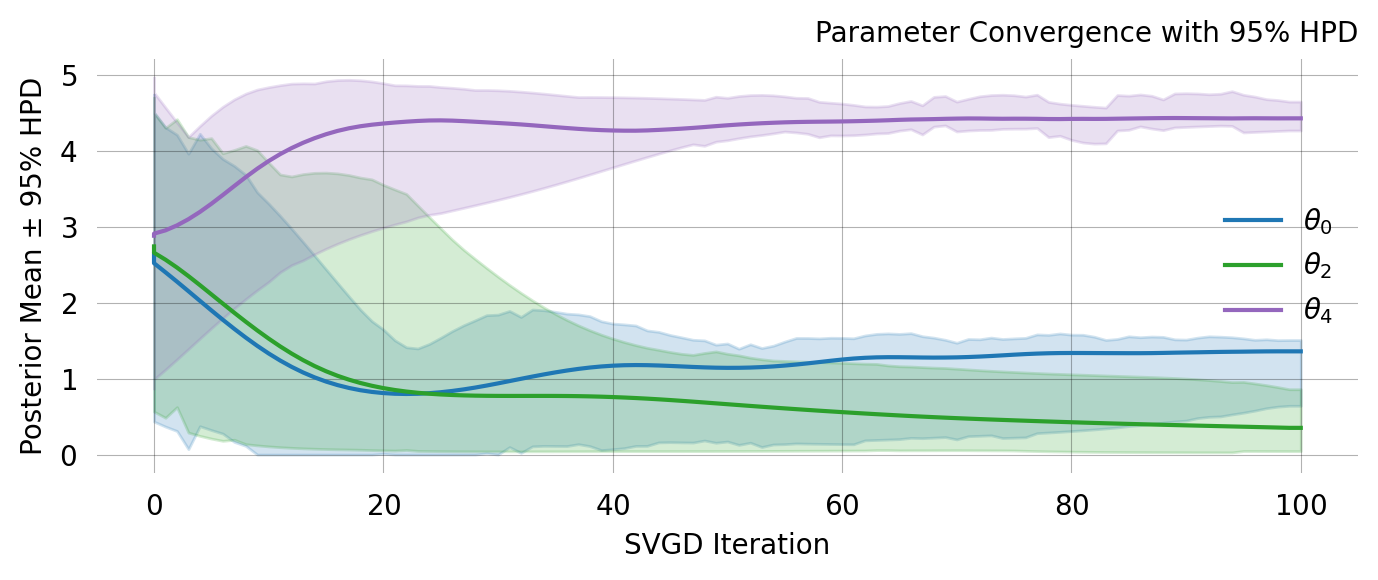

In [ ]:
svgd.plot_ci(ci_method='hpd')

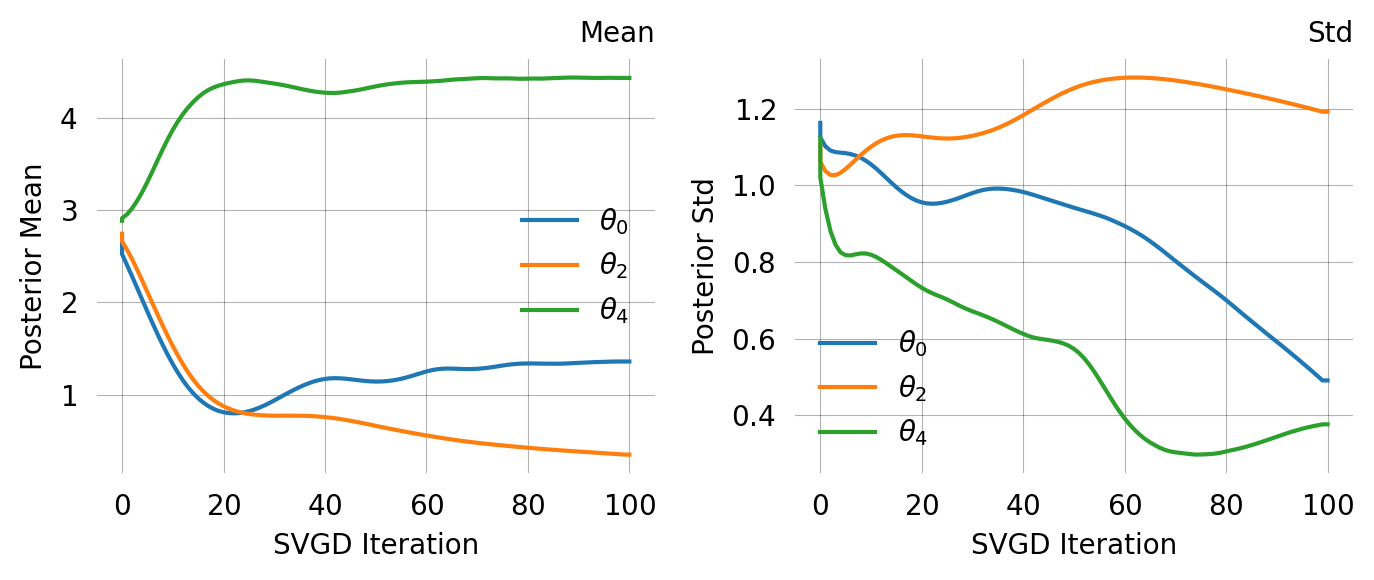

In [ ]:
svgd.plot_convergence()

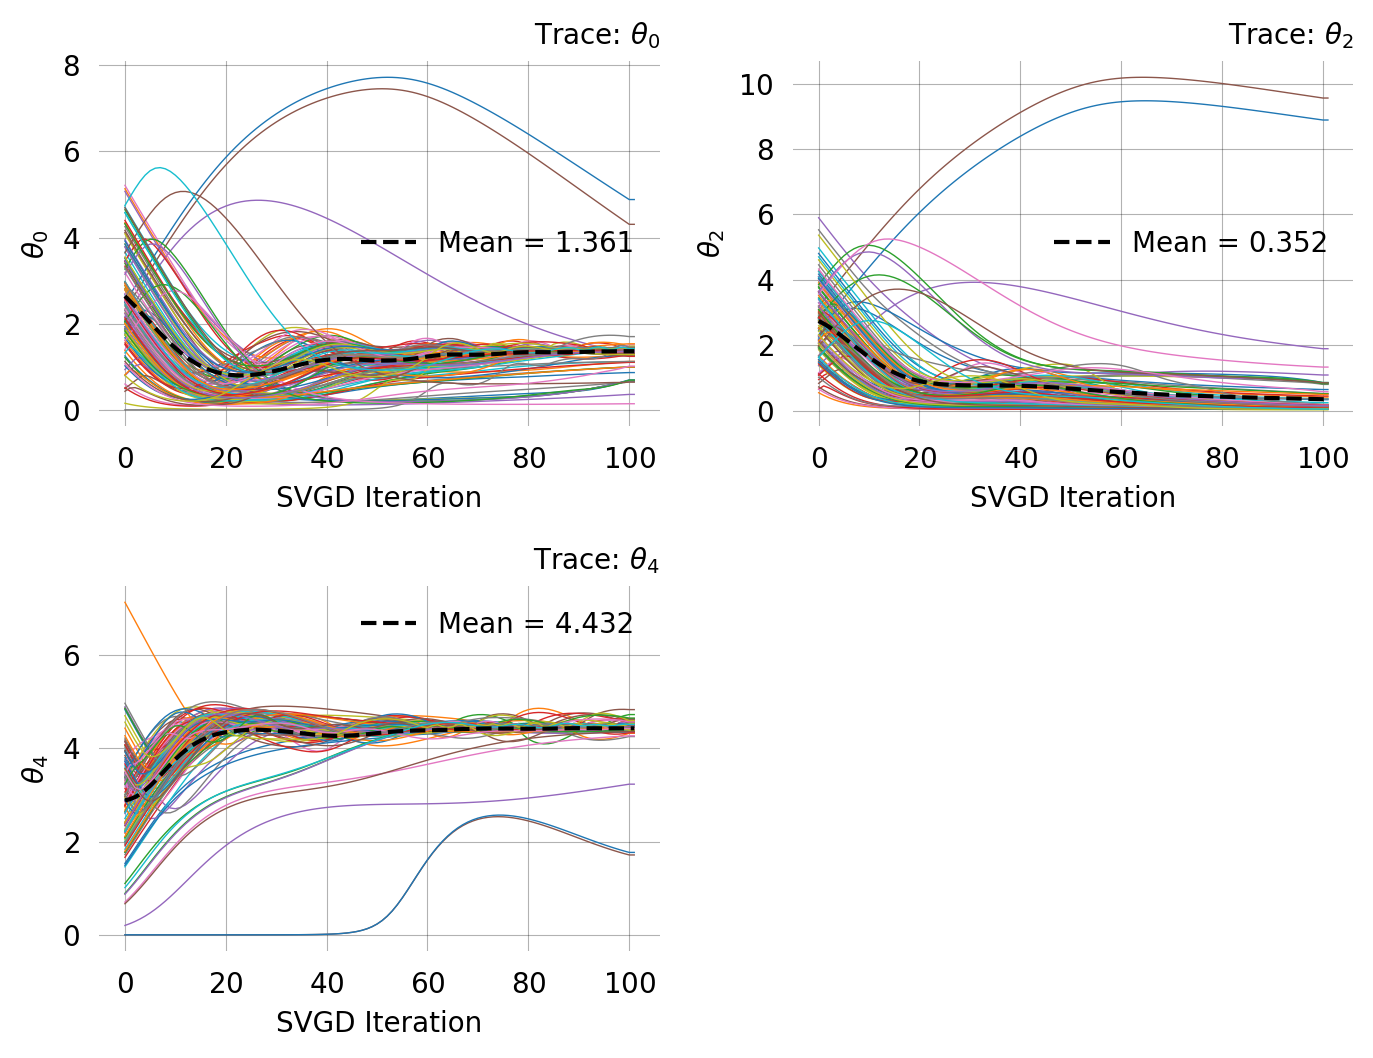

In [ ]:
svgd.plot_trace()

## ARG

In [ ]:
# create state space for two-locus model
nr_samples = 3
indexer = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples),
        Property('loc2', min_value=0, max_value=nr_samples)
    ]
)

# initial state with all lineages having one descendant at both loci
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples

@with_ipv(initial)
def two_locus_arg_2param(state, indexer=None):

    transitions = []
    if state.sum() <= 1: return transitions

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_loc1 = props_i.loc1 + props_j.loc1
            des_loc2 = props_i.loc2 + props_j.loc2
            if des_loc1 <= nr_samples and des_loc2 <= nr_samples:
                child[indexer.descendants.props_to_index(loc1=des_loc1, loc2=des_loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0 and props_i.loc1 > 0 and props_i.loc2 > 0:
            child = state.copy()
            child[i] -= 1
            child[indexer.descendants.props_to_index(loc1=0, loc2=props_i.loc2)] += 1
            child[indexer.descendants.props_to_index(loc1=props_i.loc1, loc2=0)] += 1
            transitions.append([child, [0, state[i]]])
            # transitions.append([child, [0, 1]])

    return transitions

In [ ]:
graph = Graph(two_locus_arg_2param, indexer=indexer, 
            #   graph_cache=True, 
            #   cache_trace=True
            )
graph.vertices_length()

In [ ]:
graph.plot(nodesep=0.5, wrap=False)

In [ ]:
mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(indexer,
                                           reward_only=['loc1', 'loc2'],       
                                          reward_limit=1,                                   
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )

In [ ]:
true_theta = [10, 1, mutation_rate] # coalescent, recombination, and mutation rate
observations = sample_joint_observations(joint_prob_graph, true_theta, nr_observations=1000)
observations[:5]

In [ ]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table.head()

In [ ]:
ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0).plot(100) ;

In [ ]:
%%monitor

svgd = joint_prob_graph.svgd(
    observed_data=observations, 
    fixed=[(2, mutation_rate)],
    n_iterations=100,
    n_particles=200,
    prior=[
        GaussPrior(ci=[5, 25]),
        GaussPrior(ci=[0, 3]),
        None
    ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
    )
svgd.summary()

In [ ]:
svgd.plot_ci(ci_method='hpd')

In [ ]:
svgd.plot_convergence() ;

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.map_estimate_from_particles()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_hdr(hexgrid=False) ;

In [ ]:
svgd.plot_pairwise(true_theta=true_theta) ;

In [ ]:
svgd.animate_pairwise(true_theta=true_theta)

## Example data

Simulation of two-island model:

**NB:** Simulation requires the `msprime` and `tskit` packages, both available as conda packages.

In [ ]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [ ]:
# # isolation with migration (IM) model:
# demography = msprime.Demography()
# demography.add_population(name="pop1", initial_size=pop1_size)
# demography.add_population(name="pop2", initial_size=pop2_size)
# demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
# demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
# demography.add_population(name="ancestral", initial_size=anc_pop_size)
# demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
# ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
#                           demography=demography, recombination_rate=rec_rate, 
#                           sequence_length=seq_length, random_seed=12)
# ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
# df = derived_counts(ts, rec_rate)
# df.to_csv("IM_model_derived_counts.csv", index=False)

Get pairs of variants in the specified distance range.

In [ ]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

We allow multiple SNPs from the same tree, but each SNP can only be part of a single pair. Remove pairs that share a position with another pair:

In [ ]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

Plot position differences for pairs of variants:

In [ ]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [ ]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [ ]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)

Can you make a model and find the true parameters?